# Reglas de Asociación

_Soporte, confianza, lift y el algoritmo Apriori sobre canastas de mercado_

**Módulo 2 — Aprendizaje No Supervisado** | DSRP Machine Learning Engineering
**Profesor:** Miguel Arquez

![Aprendizaje No Supervisado](assets/header.png)

## 1. ¿Qué problema resuelven?

Dado un conjunto de **transacciones** (cada una es un conjunto de ítems), queremos descubrir reglas del tipo:

$$
\{\text{pan}, \text{leche}\} \Rightarrow \{\text{mantequilla}\}
$$

Es decir: cuando alguien compra _pan y leche_, probablemente también compre _mantequilla_. Este tipo de análisis nació en el retail (**market basket analysis**) pero hoy se usa en:

- **Recomendación cruzada** ("clientes que vieron X también vieron Y").
- **Diseño de góndolas / catálogos** y promociones combinadas.
- **Detección de patrones de uso** en logs (clicks, productos contratados, etc.).
- **Análisis biomédico** (genes que se co-expresan, síntomas que aparecen juntos).

## 2. Vocabulario

- **Ítem**: un producto individual (`pan`, `leche`, …).
- **Itemset**: un conjunto de ítems ($\{$pan, leche$\}$).
- **Transacción $T$**: un itemset comprado en un evento.
- **Base de datos $D$**: el conjunto de todas las transacciones.

Una regla se escribe $A \Rightarrow B$ donde $A$ y $B$ son itemsets disjuntos. **$A$** es el _antecedente_ y **$B$** el _consecuente_.

## 3. Las tres métricas clave

### 3.1 Soporte (support)
Frecuencia con la que el itemset aparece en el conjunto de transacciones:

$$
\text{sop}(A) = \frac{|\{T \in D : A \subseteq T\}|}{|D|}
$$

Filtramos por `min_support` para ignorar combinaciones demasiado raras.

### 3.2 Confianza (confidence)
Probabilidad condicional de comprar $B$ dado que se compró $A$:

$$
\text{conf}(A \Rightarrow B) = \frac{\text{sop}(A \cup B)}{\text{sop}(A)}
$$

### 3.3 Lift
Cuánto más probable es comprar $B$ junto con $A$ comparado con comprar $B$ solo:

$$
\text{lift}(A \Rightarrow B) = \frac{\text{conf}(A \Rightarrow B)}{\text{sop}(B)} = \frac{\text{sop}(A \cup B)}{\text{sop}(A)\, \text{sop}(B)}
$$

| Lift | Interpretación |
|---|---|
| $> 1$ | $A$ y $B$ se compran juntos **más** que por azar — regla útil |
| $= 1$ | Independientes — la regla no aporta |
| $< 1$ | Se evitan entre sí (sustitutos) |

> Una regla con **alta confianza pero lift ≈ 1** suele ser engañosa: ocurre solo porque $B$ es muy popular por sí mismo (p. ej., "quien compra X también compra bolsas plásticas").

## 4. El algoritmo Apriori

La fuerza bruta es inviable: con $n$ ítems hay $2^n$ itemsets posibles. Apriori (Agrawal & Srikant, 1994) usa la **propiedad anti-monótona del soporte**:

> _"Si un itemset $A$ es infrecuente, ningún superconjunto de $A$ puede ser frecuente."_

Eso permite **podar** masivamente el espacio de búsqueda:

1. **k=1**: encontrar todos los ítems individuales con `support ≥ min_support`.
2. **k=2**: combinar pares de ítems frecuentes y mantener solo los que cumplan el soporte mínimo.
3. **k=3, k=4, ...**: combinar itemsets de tamaño $k$ frecuentes para generar candidatos de tamaño $k+1$, contar y filtrar.
4. Detener cuando no haya más candidatos frecuentes.
5. **Generar reglas** a partir de los itemsets frecuentes y filtrar por `min_confidence` (y opcionalmente `min_lift`).

Variantes más eficientes para datasets grandes: **FP-Growth** (sin generar candidatos explícitos), **Eclat**, **LCM**.

## 5. Caso práctico — canasta de mercado sintética

Para mantener el notebook autocontenido generamos un conjunto pequeño de transacciones de supermercado. En un caso real usarías el log transaccional de tu negocio o un dataset abierto como **Online Retail (UCI)** — la mecánica es exactamente la misma.

> ⚠️ Este notebook usa `mlxtend` (`uv add mlxtend` o ya incluido en `pyproject.toml`).

In [25]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)

CATALOG = [
    'pan', 'mantequilla', 'leche', 'huevos', 'cafe', 'azucar',
    'cerveza', 'pañales', 'queso', 'jamon', 'tomate', 'lechuga',
    'aceite', 'arroz', 'pasta', 'salsa_tomate',
]

# Reglas "verdaderas" que metemos a propósito (luego veremos si Apriori las recupera)
ASOCIACIONES = [
    {'pan', 'mantequilla'},
    {'pan', 'mantequilla', 'leche'},
    {'cafe', 'azucar'},
    {'cerveza', 'pañales'},        # el clásico mito del market basket
    {'pasta', 'salsa_tomate'},
    {'jamon', 'queso'},
    {'tomate', 'lechuga'},
]

N_TRANSACCIONES = 1500
transacciones = []
for _ in range(N_TRANSACCIONES):
    cesta = set()
    # 50% probabilidad de meter cada asociación (sesgada)
    for grupo in ASOCIACIONES:
        if rng.random() < 0.25:
            cesta |= grupo
    # añadir 0-4 items "ruido" cualesquiera
    extras = rng.choice(CATALOG, size=rng.integers(0, 5), replace=False)
    cesta |= set(extras)
    transacciones.append(sorted(cesta))

print(f'Generadas {len(transacciones)} transacciones')
print('Ejemplos:')
for t in transacciones[:5]:
    print(' ', t)

Generadas 1500 transacciones
Ejemplos:
  [np.str_('leche'), np.str_('lechuga'), 'pasta', np.str_('pañales'), 'salsa_tomate']
  [np.str_('aceite'), np.str_('cafe'), 'jamon', np.str_('pan'), np.str_('pasta'), 'queso']
  [np.str_('leche'), 'lechuga', 'pasta', 'salsa_tomate', 'tomate']
  [np.str_('cafe'), np.str_('cerveza'), np.str_('huevos'), 'jamon', 'lechuga', 'queso', 'tomate']
  [np.str_('arroz'), np.str_('huevos'), np.str_('salsa_tomate'), np.str_('tomate')]


In [26]:
# --- One-hot encoding: cada fila = transacción, cada columna = ítem ---
items_unicos = sorted({str(i) for t in transacciones for i in t})
basket = pd.DataFrame(
    [[item in t for item in items_unicos] for t in transacciones],
    columns=items_unicos,
)
print('Forma del basket:', basket.shape)
basket.head()

Forma del basket: (1500, 16)


,aceite,arroz,azucar,cafe,cerveza,huevos,jamon,leche,lechuga,mantequilla,pan,pasta,pañales,queso,salsa_tomate,tomate
0,False,False,False,False,False,False,False,True,True,False,False,True,True,False,True,False
1,True,False,False,True,False,False,True,False,False,False,True,True,False,True,False,False
2,False,False,False,False,False,False,False,True,True,False,False,True,False,False,True,True
3,False,False,False,True,True,True,True,False,True,False,False,False,False,True,False,True
4,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,True


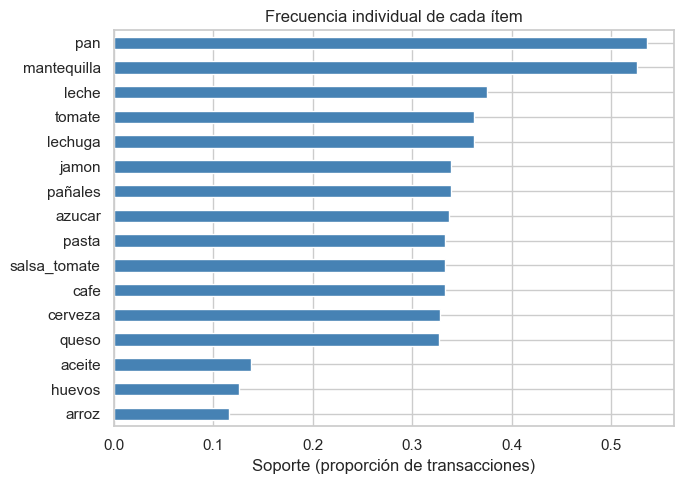

In [27]:
# --- Frecuencia individual de cada ítem ---
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

frecuencias = basket.mean().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(7, 5))
frecuencias.plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('Soporte (proporción de transacciones)')
ax.set_title('Frecuencia individual de cada ítem')
plt.tight_layout(); plt.show()

In [28]:
# --- Apriori con mlxtend ---
from mlxtend.frequent_patterns import apriori, association_rules

itemsets = apriori(basket, min_support=0.05, use_colnames=True)
itemsets['n_items'] = itemsets['itemsets'].apply(len)
print(f'Itemsets frecuentes (support ≥ 0.05): {len(itemsets)}')
itemsets.sort_values('support', ascending=False).head(15)

Itemsets frecuentes (support ≥ 0.05): 404


,support,itemsets,n_items
10,0.536667,frozenset({pan}),1
9,0.526000,frozenset({mantequilla}),1
86,0.470000,"frozenset({mantequilla, pan})",2
7,0.375333,frozenset({leche}),1
8,0.362000,frozenset({lechuga}),1
15,0.362000,frozenset({tomate}),1
6,0.339333,frozenset({jamon}),1
12,0.338667,frozenset({pañales}),1
2,0.336667,frozenset({azucar}),1
11,0.333333,frozenset({pasta}),1


In [29]:
# --- Generación de reglas: confianza ≥ 0.4 y lift ≥ 1 ---
reglas = association_rules(itemsets, metric='confidence', min_threshold=0.4)
reglas = reglas[reglas['lift'] >= 1.0].copy()
reglas['antecedents'] = reglas['antecedents'].apply(lambda s: ', '.join(sorted(s)))
reglas['consequents'] = reglas['consequents'].apply(lambda s: ', '.join(sorted(s)))

cols_show = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
reglas_top = reglas.sort_values('lift', ascending=False)[cols_show].head(15)
print(f'Reglas válidas: {len(reglas)}')
reglas_top.round(3)

Reglas válidas: 1104


,antecedents,consequents,support,confidence,lift
800,"jamon, salsa_tomate","pasta, queso",0.064,0.552,5.481
799,"pasta, queso","jamon, salsa_tomate",0.064,0.636,5.481
586,"jamon, pañales","cerveza, queso",0.073,0.609,5.405
583,"cerveza, queso","jamon, pañales",0.073,0.645,5.405
386,"azucar, cerveza","cafe, pañales",0.062,0.571,5.349
389,"cafe, pañales","azucar, cerveza",0.062,0.581,5.349
468,"azucar, salsa_tomate","cafe, pasta",0.052,0.494,5.289
471,"cafe, pasta","azucar, salsa_tomate",0.052,0.557,5.289
387,"azucar, pañales","cafe, cerveza",0.062,0.571,5.218
388,"cafe, cerveza","azucar, pañales",0.062,0.567,5.218


**Cómo leer la tabla:**
- Las primeras filas (lift más alto) deberían recuperar las asociaciones que sembramos: _pan ⇒ mantequilla_, _café ⇒ azúcar_, _cerveza ⇒ pañales_, _pasta ⇒ salsa_tomate_, etc.
- Si una regla tiene **alta confianza pero lift cerca de 1**, lo que está midiendo es que el consecuente es muy popular per se (no aporta como recomendación).

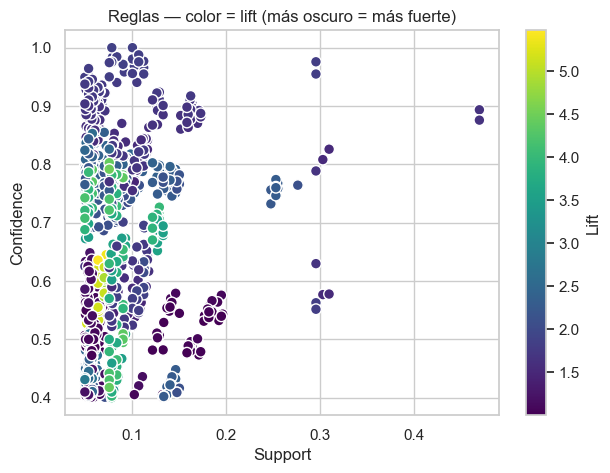

In [30]:
# --- Visualización: scatter support vs confidence, color = lift ---
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(
    reglas['support'], reglas['confidence'],
    c=reglas['lift'], cmap='viridis', s=60, edgecolor='white',
)
ax.set_xlabel('Support'); ax.set_ylabel('Confidence')
ax.set_title('Reglas — color = lift (más oscuro = más fuerte)')
plt.colorbar(sc, ax=ax, label='Lift')
plt.show()

In [31]:
# --- Vista de "recomendación": dado un producto, qué sugerir ---
def recomendar(reglas_df, comprado, top=5):
    """Devuelve las mejores reglas cuyo antecedente es exactamente `comprado`."""
    filtradas = reglas_df[reglas_df['antecedents'] == comprado]
    return (
        filtradas.sort_values('lift', ascending=False)
                 [['consequents', 'support', 'confidence', 'lift']]
                 .head(top)
                 .round(3)
                 .reset_index(drop=True)
    )

print('Recomendaciones para quien compra "pan":')
recomendar(reglas, 'pan')

Recomendaciones para quien compra "pan":


,consequents,support,confidence,lift
0,"leche, mantequilla",0.296,0.552,1.818
1,mantequilla,0.470,0.876,1.665
2,leche,0.310,0.578,1.539


In [32]:
print('Recomendaciones para quien compra "cafe":')
recomendar(reglas, 'cafe')

Recomendaciones para quien compra "cafe":


,consequents,support,confidence,lift
0,"azucar, pan",0.142,0.427,2.354
1,"azucar, mantequilla",0.140,0.421,2.304
2,azucar,0.255,0.768,2.280
3,tomate,0.141,0.425,1.174
4,leche,0.141,0.425,1.132


## 6. Cómo elegir los umbrales

`min_support` y `min_confidence` son **decisiones de negocio**, no estadísticas:

- Bajar `min_support` → más itemsets, costo computacional explota, aparecen reglas espurias.
- Subir `min_support` → solo descubres lo obvio (los ítems muy populares).
- `min_confidence` alto → reglas casi deterministas pero con poco soporte.
- Mirar siempre **lift** además de confianza para filtrar reglas triviales.

Una receta práctica:
1. Empezar con `min_support` igual a la frecuencia del ítem ~10º más vendido.
2. Pedir `min_confidence ≥ 0.3-0.5` y `lift ≥ 1.2`.
3. Revisar el top con el negocio: ¿son reglas accionables o cosas obvias?
4. Iterar.

## 7. FP-Growth — alternativa más rápida

Cuando el catálogo crece (miles de ítems), Apriori se vuelve lento por la generación de candidatos. **FP-Growth** comprime las transacciones en un árbol (FP-tree) y extrae itemsets frecuentes sin generar candidatos explícitos. La API en `mlxtend` es idéntica:

In [21]:
from mlxtend.frequent_patterns import fpgrowth

itemsets_fp = fpgrowth(basket, min_support=0.05, use_colnames=True)
print(f'FP-Growth devolvió {len(itemsets_fp)} itemsets — los mismos que Apriori (más rápido).')

FP-Growth devolvió 404 itemsets — los mismos que Apriori (más rápido).


## 8. Limitaciones que vale la pena conocer

- **No infiere causalidad**: que dos productos se compren juntos no significa que uno cause al otro. Pueden tener una causa común (estación, promoción, vecindario).
- **Reglas obvias**: muchas veces se filtra "todo el mundo compra bolsas" — hay que limpiar el catálogo o subir el lift.
- **Datos esparsos**: con pocos ítems repetidos por canasta, el soporte cae mucho.
- **Tiempo**: el orden temporal se pierde. Si te importa _qué se compra después de qué_, mira **sequential pattern mining** (PrefixSpan, SPADE).

## 9. Referencias

- Agrawal, R. & Srikant, R. (1994). *Fast Algorithms for Mining Association Rules*.
- Han, J., Pei, J. & Yin, Y. (2000). *Mining Frequent Patterns without Candidate Generation* (FP-Growth).
- mlxtend — Frequent Patterns: https://rasbt.github.io/mlxtend/user_guide/frequent_patterns/apriori/
- Online Retail dataset (real, para profundizar): https://archive.ics.uci.edu/dataset/352/online+retail
- Aggarwal, C. C. (2014). *Frequent Pattern Mining*.

## Predicción sobre datos nuevos — uso del modelo en producción

A diferencia de un modelo supervisado, en reglas de asociación **no persistimos un "modelo"** sino la **tabla de reglas**. La inferencia es una búsqueda: dada la canasta actual del usuario, devolver las reglas cuyo antecedente coincide y ordenarlas por lift.

In [22]:
# 1. Persistir las reglas como tabla (CSV / parquet) para el servicio de recomendación
reglas_export = reglas[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
reglas_export.to_csv('reglas_asociacion.csv', index=False)
print(f'Guardadas {len(reglas_export)} reglas en reglas_asociacion.csv')

Guardadas 1104 reglas en reglas_asociacion.csv


In [23]:
# 2. Función de recomendación en línea
def recomendar_canasta(canasta_actual, reglas_df, top=5, min_lift=1.0):
    """Recomienda productos dado el conjunto actual del usuario."""
    canasta_actual = set(canasta_actual)
    sugerencias = []
    for _, r in reglas_df.iterrows():
        antecedente = set(r['antecedents'].split(', '))
        consecuente = set(r['consequents'].split(', '))
        # antecedente cubierto y consecuente aún no en canasta
        if antecedente.issubset(canasta_actual) and not consecuente & canasta_actual:
            if r['lift'] >= min_lift:
                sugerencias.append({
                    'sugerencia': ', '.join(sorted(consecuente)),
                    'lift':       round(r['lift'], 2),
                    'confidence': round(r['confidence'], 2),
                    'support':    round(r['support'], 3),
                })
    return (
        pd.DataFrame(sugerencias)
        .sort_values('lift', ascending=False)
        .drop_duplicates('sugerencia')
        .head(top)
        .reset_index(drop=True)
    )

print('Carrito actual: pan + leche')
recomendar_canasta(['pan', 'leche'], reglas)

Carrito actual: pan + leche


,sugerencia,lift,confidence,support
0,mantequilla,1.82,0.95,0.296


In [24]:
print('Carrito actual: pasta')
recomendar_canasta(['pasta'], reglas)

Carrito actual: pasta


,sugerencia,lift,confidence,support
0,"pan, salsa_tomate",2.32,0.42,0.141
1,salsa_tomate,2.28,0.76,0.253
2,"mantequilla, salsa_tomate",2.28,0.40,0.134


**Lecciones para producción:**
- Reentrenar las reglas cada cierto tiempo: el catálogo cambia, las modas cambian.
- Combinar las reglas con un **filtrado por inventario** (no recomendar lo que está agotado) y por **margen** (priorizar productos rentables).
- Para sistemas a gran escala (millones de transacciones, miles de ítems), pasar de Apriori a **FP-Growth** o frameworks distribuidos (`pyspark.ml.fpm.FPGrowth`).
- Evaluar la calidad **A/B testando** las recomendaciones en producción — el lift offline no garantiza un mejor _click-through_.